# Обучение моделей: цена в объявлении

Задача - предсказать, какую цену следует поставить, чтобы продать квартиру за желаемый срок. Целевой признак - price_per_m2. Считаем по тем же закрытым объявлениям, что и в модели ликвидности

# Импортируем библиотеки

In [2]:
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# простые модели
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
# Ансамбли
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, make_scorer


# Строим функции и фиксируем константы

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [4]:
def preprocessor_creator(ohe_cols,
                         num_cols):
    '''
    Функция для построения пайплайна кодирования данных
    Категориальные признаки кодируем ohe, числовые шкалером
    '''

    # кодировщик категориальных признаков
    ohe_pipe = Pipeline(
        [
            ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='first',
                                  handle_unknown='ignore',
                                  sparse_output=True))
        ]
    )

    # кодировщик числовых признаков
    scaler_pipe = Pipeline(
        [
            ('simpleImputer_num', SimpleImputer(strategy='median')),
            ('standard', StandardScaler(with_mean=False))
        ]
    )

    data_preprocessor = ColumnTransformer([
        ('ohe', ohe_pipe, ohe_cols),
        ('num', scaler_pipe, num_cols)])

    return data_preprocessor

In [5]:
def col_names_func(df):
    '''
    функция для разделения столбцов по типам
    '''
    num_col_names = df.select_dtypes(include='number').columns.tolist()
    cat_col_names = df.select_dtypes(exclude='number').columns.tolist()
    return num_col_names, cat_col_names

In [6]:
def evaluate_model(y_true, y_pred):
    '''
    Принимает фактические значения и предсказания
    Выводит на экран основные метрики регрессии и возвращает их значения
    '''
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.3f}')

    return mae, rmse, r2

# Загрузка данных

In [7]:
df = pd.read_csv('./notebooks/data/data_final.csv')
df.shape

(132188, 67)

## Отбор модельных признаков

In [8]:
# убираем производные от цены типа ppm_to_district и last_price
num_cols = [
    'mortgage_allowed', 'n_metro', 'nearest_metro_time', 'nearest_metro_walk', 'rooms', 'is_studio',
    'total_area', 'living_area', 'kitchen_area', 'floor', 'total_floors', 'ceiling_height',
    'is_apartments', 'is_new_building', 'phone_protected', 'lat', 'lon', 'dist_to_center',
    'building_age', 'is_ready', 'is_first_floor', 'is_last_floor', 'floor_ratio',
    'living_to_total', 'kitchen_to_total', 'area_per_room',
    'total_lifts', 'has_lift', 'bath_separate', 'bath_combined', 'balcony_count', 'loggia_count',
    'completion_year', 'years_to_completion', 'is_presale', 'has_completion',
    'demolished_in_renovation', 'is_penthouse', 'seller_is_owner',
    'days_on_market'
]
cat_cols = ['region', 'flat_type', 'renovation', 'window_view', 'building_type', 'parking',
            'seller_type', 'seller_user_type', 'room_type', 'deal_conditions', 'municipality', 'district']

df = df[num_cols + cat_cols + ['price_per_m2']].copy()
display(df.shape)
display(df.head())

(132188, 53)

,mortgage_allowed,n_metro,nearest_metro_time,nearest_metro_walk,rooms,is_studio,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,is_apartments,is_new_building,phone_protected,lat,lon,dist_to_center,building_age,is_ready,is_first_floor,is_last_floor,floor_ratio,living_to_total,kitchen_to_total,area_per_room,total_lifts,has_lift,bath_separate,bath_combined,balcony_count,loggia_count,completion_year,years_to_completion,is_presale,has_completion,demolished_in_renovation,is_penthouse,seller_is_owner,days_on_market,region,flat_type,renovation,window_view,building_type,parking,seller_type,seller_user_type,room_type,deal_conditions,municipality,district,price_per_m2
0,0,3,21.000,0,1,0,38.050,16.000,11.000,1,5,3.150,0,0,1,56.063,37.358,38.149,0,1,1,0,0.200,0.420,0.289,38.050,2,1,-1,-1,-1,-1,2025.000,-1.000,0,1,0,0,0,525,Московская область,rooms,unknown,unknown,monolithBrick,unknown,agency,unknown,unknown,free,Дмитровский муниципальный округ,unknown,199861.445
1,1,3,12.000,1,2,0,68.300,28.000,20.200,5,18,3.360,0,0,1,55.813,37.427,13.675,6,1,0,0,0.278,0.410,0.296,34.150,4,1,2,0,1,0,2028.000,2.000,1,1,0,0,0,524,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,730700.000
2,1,3,12.000,1,3,0,92.100,40.100,24.600,10,18,3.360,0,0,1,55.813,37.427,13.675,6,1,0,0,0.556,0.435,0.267,30.700,4,1,2,0,1,0,2028.000,2.000,1,1,0,0,0,524,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,749600.000
3,1,3,12.000,1,2,0,66.700,27.600,24.600,14,18,3.360,0,0,1,55.813,37.427,13.675,6,1,0,0,0.778,0.414,0.369,33.350,4,1,1,0,2,0,2028.000,2.000,1,1,0,0,0,527,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,806400.000
4,1,3,12.000,1,3,0,81.200,33.400,28.900,7,22,3.380,0,0,1,55.813,37.427,13.675,6,1,0,0,0.318,0.411,0.356,27.067,4,1,2,0,-1,-1,2028.000,2.000,1,1,0,0,0,524,Москва,rooms,unknown,unknown,monolith,underground,agency,unknown,unknown,fz214,СЗАО,Покровское-Стрешнево,732900.000


# Модель

In [10]:
# Целевой признак регрессии - цена за м2
y_reg = df['price_per_m2'].astype(float)
X_reg = df.drop(columns='price_per_m2')

X_train, X_test, y_train, y_test = train_test_split(X_reg,
                                                    y_reg,
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE)

num_cols, cat_cols = col_names_func(X_train)
preprocessor = preprocessor_creator(cat_cols, num_cols)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

display(X_train_encoded.shape)
display(X_test_encoded.shape)

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [10, 11] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(105750, 421)

(26438, 421)

Прогоняем кросс-валидацию с поиском по сетке. Сначала простые модели (линейная регрессия и дерево) как бейзлайн, потом бустинг. Данных много (140к строк), поэтому из бустингов взял только LGBM. Метрика - RMSE.

In [9]:
pipe_reg = Pipeline([('models', LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))])
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

simple_reg_params = [
        # Линейная регрессия
        {
            'models': [LinearRegression()]
        },

        # Дерево решений
        {
            'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
            'models__max_depth': [6, 9, 12],
            'models__min_samples_leaf': [30, 60]
        }
]

rscv = RandomizedSearchCV(
    pipe_reg,
    simple_reg_params,
    n_iter=6,
    cv=kf,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_simple_reg = rscv.fit(X_train_encoded, y_train)
simple_reg = rscv_simple_reg.best_estimator_

print('Лучшая простая модель:', simple_reg['models'])
print('Метрики на тесте')
evaluate_model(y_test, simple_reg.predict(X_test_encoded))

Лучшая простая модель: DecisionTreeRegressor(max_depth=12, min_samples_leaf=30, random_state=42)
Метрики на тесте
MAE: 38682.82
RMSE: 59407.26
R2: 0.867


(38682.816008951326, np.float64(59407.257615246344), 0.8670470482955095)

In [10]:
boosters_reg_params = [
        # LGBM
        {
            'models': [LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)],
            'models__n_estimators': [500, 1000, 1500],
            'models__learning_rate': [0.03, 0.05],
            'models__num_leaves': [60, 120],
            'models__subsample': [0.8, 1.0],
            'models__colsample_bytree': [0.8, 1.0],
            'models__reg_lambda': [0.0, 1.0]
        }
]

rscv = RandomizedSearchCV(
    pipe_reg,
    boosters_reg_params,
    n_iter=10,
    cv=kf,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_boost_reg = rscv.fit(X_train_encoded, y_train)
model_reg = rscv_boost_reg.best_estimator_

print('Лучший бустинг:', model_reg['models'])
print('Метрики лучшей модели на трейне')
evaluate_model(y_train, model_reg.predict(X_train_encoded))
print()
print('Метрики лучшей модели на тесте')
evaluate_model(y_test, model_reg.predict(X_test_encoded))

Лучший бустинг: LGBMRegressor(learning_rate=0.05, n_estimators=1500, num_leaves=120,
              random_state=42, reg_lambda=1.0, subsample=0.8, verbose=-1)
Метрики лучшей модели на трейне


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 13887.31
RMSE: 20130.15
R2: 0.985

Метрики лучшей модели на тесте


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 23561.44
RMSE: 38618.39
R2: 0.944


(23561.437600366935, np.float64(38618.393437832616), 0.9438166825160168)

Важность признаков регрессора.

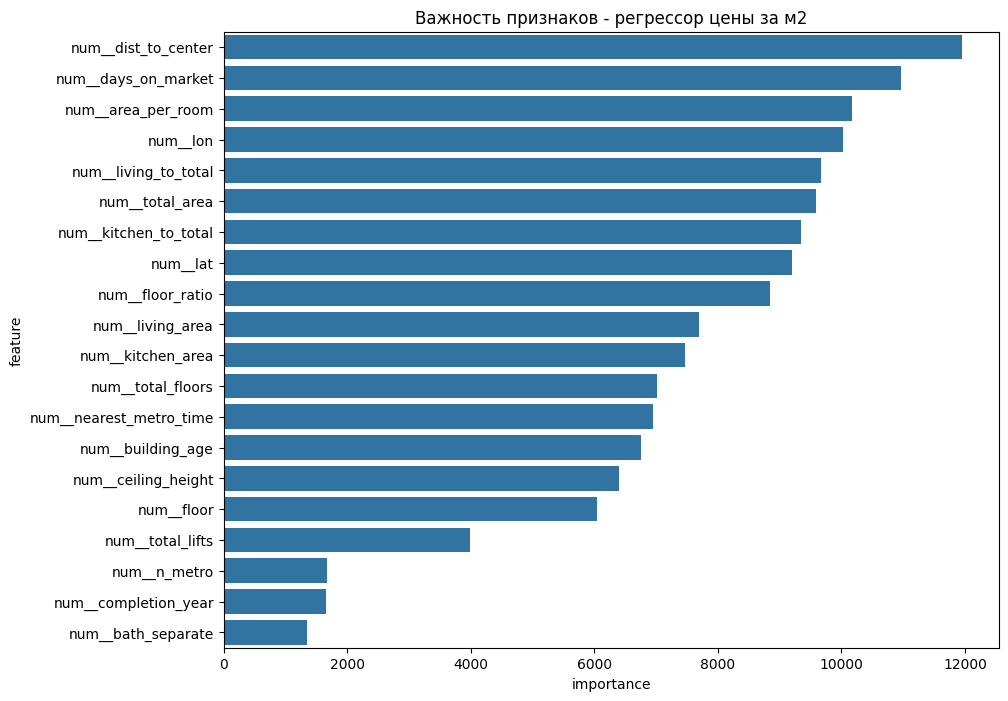

In [11]:
imp_reg = pd.DataFrame({
    'feature': feature_names,
    'importance': model_reg['models'].feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=imp_reg)
plt.title('Важность признаков - регрессор цены за м2')
plt.show()

Самые важные показатели для цены - это:
- показатели местонахождения квартиры (расстояние до центра, широта и долгота)
- микропоказатели квартиры (площадь, доля жилой площади) 
- количество дней, которое квартира будет оставаться на рынке

### Восстановление полной цены

In [12]:
# Восстановление полной цены объявления для валидации
pred_ppm2 = model_reg.predict(X_test_encoded)
pred_price = pred_ppm2 * X_test['total_area'].values
true_price = y_test.values * X_test['total_area'].values

print('Метрики по полной цене объявления (руб)')
evaluate_model(true_price, pred_price)

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Метрики по полной цене объявления (руб)
MAE: 1361805.64
RMSE: 2573053.67
R2: 0.959


(1361805.6373380215, np.float64(2573053.673628667), 0.9593210032082767)

### Нейросеть для регрессии

In [11]:
# импорт нейронки
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# если в системе есть видеокарта - считаем на ней
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Устройство для обучения:', device)

# переводим данные в тензоры
X_train_dense = X_train_encoded.toarray().astype('float32')
X_test_dense = X_test_encoded.toarray().astype('float32')

X_train_t = torch.tensor(X_train_dense)
X_test_t = torch.tensor(X_test_dense)

# шкалируем цену
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).astype('float32')

y_train_t = torch.tensor(y_train_scaled)

# заворачиваем трейн в DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

print('Размер обучающей матрицы:', X_train_t.shape)

Устройство для обучения: cuda
Размер обучающей матрицы: torch.Size([105750, 421])


In [12]:
# нейросеть
class Net(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# отправляем нейронку на GPU
model = Net(X_train_t.shape[1]).to(device)
print(model)

Net(
  (fc1): Linear(in_features=421, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)


In [13]:
# берём mse как функцию потерь
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# задаём количество эпох
epochs = 100
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        # переносим батч на видеокарту
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # средняя ошибка за эпоху по всем батчам
    mean_loss = epoch_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f'Эпоха {epoch + 1}/{epochs}, ошибка (MSE): {mean_loss:.4f}')

Эпоха 10/100, ошибка (MSE): 0.1663
Эпоха 20/100, ошибка (MSE): 0.1446
Эпоха 30/100, ошибка (MSE): 0.1297
Эпоха 40/100, ошибка (MSE): 0.1181
Эпоха 50/100, ошибка (MSE): 0.1143
Эпоха 60/100, ошибка (MSE): 0.1073
Эпоха 70/100, ошибка (MSE): 0.1034
Эпоха 80/100, ошибка (MSE): 0.1019
Эпоха 90/100, ошибка (MSE): 0.0973
Эпоха 100/100, ошибка (MSE): 0.0937


In [14]:
# смотрим качество на тесте
model.eval()
with torch.no_grad():
    y_pred_nn_scaled = model(X_test_t.to(device)).cpu().numpy().reshape(-1, 1)

# возвращаем предсказание из стандартизованной шкалы обратно в руб/м2
y_pred_nn = y_scaler.inverse_transform(y_pred_nn_scaled).reshape(-1)

print('Метрики нейросети на тесте')
evaluate_model(y_test, y_pred_nn)

Метрики нейросети на тесте
MAE: 33963.00
RMSE: 52309.30
R2: 0.897


(33962.99515667955, np.float64(52309.298483328035), 0.8969194408529523)

# Выводы

лучшая модель - lgbm с метрикой mae=24000 рублей за квадратный метр. Нейронка отработала ещё хуже относительно lgbm, чем в задаче прогнозирования квартир